# NB04 — Wildfire Detection: Daily + Hourly Pipeline

**Goal:** Detect wildfire events (binary classification) on an **imbalanced dataset** (~8-9 % positive class).

## Part A — Daily Detection (30-day horizon)
**Models:** XGBoost · CatBoost (2 baselines + 2 Optuna-tuned = 4 candidates)  
**Input:** `data/processed/engineered_daily.parquet`  
**Output:** `models/wildfire/best_fire_model.joblib`

## Part B — Hourly Detection (168-hour horizon)
**Models:** XGBoost · CatBoost (2 baselines + 2 Optuna-tuned = 4 candidates)  
**Input:** `data/processed/engineered_hourly.parquet`  
**Output:** `models/wildfire/best_fire_model_hourly.joblib`

## Anti-Overfitting Safeguards
| Measure | Implementation |
|---------|---------------|
| **3-way temporal split** | train (< 2024), val (2024), test (≥ 2025) |
| **Early stopping** | on **validation set** — test is never seen during training |
| **Feature pruning** | drop near-zero-variance + highly correlated (r > 0.95) |
| **Optuna precision floor** | reject any trial with precision < 30 % |
| **Overfitting monitor** | train-vs-val metric gap printed for every model |

In [1]:
# ─── Cell 1: Imports & paths ─────────────────────────────────────────────
import subprocess, sys, os, warnings, json, time
from pathlib import Path

for _p in ["xgboost","catboost","optuna",
           "scikit-learn","shap","joblib","tqdm"]:
    try: __import__(_p.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _p])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score)
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump as jl_dump
import xgboost as xgb, catboost as cb
import optuna
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# ── Paths (src.config) ───────────────────────────────────────────────────
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src.config import (ROOT, PROCESSED, MODELS_F, FIGURES, METRICS,
                         TARGET_COL, DROP_COLS, RANDOM_SEED,
                         ENG_DAILY, MASTER_DAILY, ENG_HOURLY)
from src.evaluation import fire_metrics, find_optimal_threshold, build_fire_leaderboard
from src.visualization import (plot_confusion_matrix, plot_pr_curves,
                                plot_feature_importance, plot_leaderboard)

SEED = RANDOM_SEED
np.random.seed(SEED)

# ── Hard metric gates ────────────────────────────────────────────────────
MIN_PRECISION = 0.30
MIN_RECALL    = 0.70
MIN_F1        = 0.40

print(f"Root : {ROOT}")
print(f"Targets : Precision≥{MIN_PRECISION}  Recall≥{MIN_RECALL}  F1≥{MIN_F1}")

Root : /home/manheim666/Desktop/WildFire-Prediction
Targets : Precision≥0.3  Recall≥0.7  F1≥0.4


## §1 — Load Data & 3-Way Temporal Split

Split strictly by time to prevent any look-ahead leakage:
- **Train:** all dates before 2024-01-01
- **Validation:** 2024-01-01 → 2024-12-31 (for early stopping, threshold tuning, calibration)
- **Test:** 2025-01-01 onward (touched **only** at final evaluation)

In [2]:
# ─── §1: Load & split ────────────────────────────────────────────────────
data_path = ENG_DAILY if ENG_DAILY.exists() else MASTER_DAILY
df = pd.read_parquet(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}  from {data_path.name}")
print(f"Fire rate: {df[TARGET_COL].mean()*100:.2f}%  ({df[TARGET_COL].sum()} fires / {len(df)} rows)")

# ── Temporal split ────────────────────────────────────────────────────────
VAL_DATE  = "2024-01-01"
TEST_DATE = "2025-01-01"

train_df = df[df["Date"] <  VAL_DATE].copy()
val_df   = df[(df["Date"] >= VAL_DATE) & (df["Date"] < TEST_DATE)].copy()
test_df  = df[df["Date"] >= TEST_DATE].copy()

# ── Feature columns ──────────────────────────────────────────────────────
exclude = set(DROP_COLS) | {"City", "Date", "Timestamp", "Year"}
feature_cols = [c for c in df.columns
                if c not in exclude
                and c != TARGET_COL
                and df[c].dtype in ("float64","float32","int64","int32","uint8")]

X_train, y_train = train_df[feature_cols].fillna(0), train_df[TARGET_COL]
X_val,   y_val   = val_df[feature_cols].fillna(0),   val_df[TARGET_COL]
X_test,  y_test  = test_df[feature_cols].fillna(0),  test_df[TARGET_COL]

IMBALANCE_RATIO = round((y_train == 0).sum() / max((y_train == 1).sum(), 1), 1)

print(f"\n{'Split':10s} {'Rows':>7s} {'Fire%':>7s} {'Fires':>6s}")
print("-" * 40)
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:10s} {len(y):7,d} {y.mean()*100:6.2f}% {int(y.sum()):6d}")
print(f"\nImbalance ratio (neg/pos): {IMBALANCE_RATIO}")
print(f"Features: {len(feature_cols)}")

Loaded: (83504, 269)  from engineered_daily.parquet
Fire rate: 8.07%  (6740 fires / 83504 rows)

Split         Rows   Fire%  Fires
----------------------------------------
Train       69,840   8.32%   5813
Val          5,856   6.11%    358
Test         7,808   7.29%    569

Imbalance ratio (neg/pos): 11.0
Features: 259


## §2 — Feature Pruning

Remove noise to reduce overfitting:
1. **Near-zero variance** (std < 0.001) — constant columns carry no signal
2. **High correlation** (|r| > 0.95) — keep the one more correlated with fire
3. Print how many survive

In [3]:
# ─── §2: Feature pruning ─────────────────────────────────────────────────
n_before = len(feature_cols)

# 2a. Near-zero variance
stds = X_train.std()
low_var = stds[stds < 0.001].index.tolist()
print(f"Near-zero variance columns removed: {len(low_var)}")

# 2b. High correlation
keep_cols = [c for c in feature_cols if c not in low_var]
corr = X_train[keep_cols].corr().abs()
fire_corr = X_train[keep_cols].corrwith(y_train).abs()

to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            ci, cj = corr.columns[i], corr.columns[j]
            if ci in to_drop or cj in to_drop:
                continue
            # Drop the one LESS correlated with fire
            drop = cj if fire_corr.get(ci, 0) >= fire_corr.get(cj, 0) else ci
            to_drop.add(drop)

print(f"Highly correlated columns removed: {len(to_drop)}")

feature_cols = [c for c in keep_cols if c not in to_drop]
X_train = X_train[feature_cols]
X_val   = X_val[feature_cols]
X_test  = X_test[feature_cols]

print(f"\nFeatures: {n_before} → {len(feature_cols)} (removed {n_before - len(feature_cols)})")

# Quick sanity check: top-10 fire-correlated features
fc = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
print("\nTop 10 features by |correlation| with Fire_Occurred:")
for feat, val in fc.head(10).items():
    print(f"  {feat:45s} {val:+.4f}")

Near-zero variance columns removed: 0
Highly correlated columns removed: 75

Features: 259 → 184 (removed 75)

Top 10 features by |correlation| with Fire_Occurred:
  fire_count_14d                                +0.3705
  fire_count_7d                                 +0.3644
  fire_count_30d                                +0.3527
  city_month_fire_rate                          +0.3182
  fire_count_90d                                +0.2486
  Soil_Moisture_max                             -0.2124
  temp_x_wind                                   +0.2050
  FFMC_proxy                                    +0.2012
  FWI_proxy                                     +0.1994
  Soil_Temp_C_max                               +0.1974


## §3 — Cost-Sensitive Baselines (XGBoost + CatBoost)

Train only **XGBoost** and **CatBoost** with built-in class weighting. These are the strongest performers on this dataset — LightGBM and SMOTEENN variants were tested in earlier iterations and consistently underperformed.

In [4]:
# ─── §3: Train 2 cost-sensitive baselines ─────────────────────────────────
results = {}   # name → { model, y_true, y_pred, y_prob, threshold, ... }

MODELS = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=IMBALANCE_RATIO,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=30,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05,
        auto_class_weights="Balanced", l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0),
}

print(f"Training {len(MODELS)} baseline models …\n")
print(f"{'Model':15s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Tr-F1':>6s} {'Gap':>6s} {'Time':>6s} {'Pass?':>6s}")
print("-" * 90)

for name, model in MODELS.items():
    t0 = time.time()
    try:
        if "XGB" in name:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        else:
            model.fit(X_train, y_train)

        y_prob_val  = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_prob_train = model.predict_proba(X_train)[:, 1]

        best_thresh = find_optimal_threshold(
            y_val, y_prob_val,
            min_precision=MIN_PRECISION, min_recall=MIN_RECALL)

        y_pred_test  = (y_prob_test >= best_thresh).astype(int)
        y_pred_train = (y_prob_train >= best_thresh).astype(int)

        m = fire_metrics(y_test, y_pred_test, y_prob_test)
        train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
        gap = train_f1 - m["f1"]

        results[name] = {
            "model": model, "y_true": y_test, "y_pred": y_pred_test,
            "y_prob": y_prob_test, "threshold": best_thresh,
            "imbalance_strategy": "class_weight",
            "train_time": time.time() - t0,
            "train_f1": train_f1, "overfit_gap": gap,
        }

        passes = (m["precision"] >= MIN_PRECISION and
                  m["recall"] >= MIN_RECALL and
                  m["f1"] >= MIN_F1)
        flag = "  ✓" if passes else "  ✗"
        print(f"{name:15s} {best_thresh:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
              f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {train_f1:6.3f} "
              f"{gap:+6.3f} {time.time()-t0:5.1f}s{flag}")

    except Exception as e:
        print(f"{name:15s} FAILED: {e}")

print(f"\nBaseline models trained: {len(results)}")

Training 2 baseline models …

Model             Thr  Recall    Prec      F1  PR-AUC  Tr-F1    Gap   Time  Pass?
------------------------------------------------------------------------------------------
XGBoost          0.50  0.7293  0.2856  0.4105  0.3859  0.454 +0.043  19.2s  ✗
CatBoost         0.50  0.6714  0.3322  0.4444  0.4093  0.532 +0.088  32.2s  ✗

Baseline models trained: 2


## §4 — Optuna Hyperparameter Tuning

Tune **both** XGBoost and CatBoost with 50 trials each. Objective: composite score (0.3×Recall + 0.3×Precision + 0.4×F1), rejecting any trial with precision < 30 % or recall < 70 %.

In [5]:
# ─── §4: Optuna tuning — XGBoost + CatBoost ──────────────────────────────
N_TRIALS = 50

def _xgb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("mcw", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha":        trial.suggest_float("alpha", 1e-6, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight": trial.suggest_float("spw", ir*0.3, ir*1.5),
    }
    clf = xgb.XGBClassifier(**p, eval_metric="aucpr",
        early_stopping_rounds=20, random_state=SEED,
        use_label_encoder=False, n_jobs=-1)
    clf.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    prec = precision_score(yv, yd, zero_division=0)
    rec  = recall_score(yv, yd, zero_division=0)
    f1v  = f1_score(yv, yd, zero_division=0)
    if prec < MIN_PRECISION or rec < MIN_RECALL:
        return 0.0
    return 0.3 * rec + 0.3 * prec + 0.4 * f1v

def _cb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "iterations":       trial.suggest_int("iterations", 200, 800),
        "depth":            trial.suggest_int("depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "l2_leaf_reg":      trial.suggest_float("l2", 0.1, 10.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
    }
    clf = cb.CatBoostClassifier(**p, auto_class_weights="Balanced",
                                random_seed=SEED, verbose=0)
    clf.fit(Xtr, ytr)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    prec = precision_score(yv, yd, zero_division=0)
    rec  = recall_score(yv, yd, zero_division=0)
    f1v  = f1_score(yv, yd, zero_division=0)
    if prec < MIN_PRECISION or rec < MIN_RECALL:
        return 0.0
    return 0.3 * rec + 0.3 * prec + 0.4 * f1v

# ── Run Optuna for both models ───────────────────────────────────────────
for base_name, obj_fn_factory in [("XGBoost", _xgb_objective), ("CatBoost", _cb_objective)]:
    print(f"\n{'='*60}\n  OPTUNA — {base_name} ({N_TRIALS} trials)\n{'='*60}")
    obj_fn = lambda trial: obj_fn_factory(trial, X_train, y_train, X_val, y_val, IMBALANCE_RATIO)
    study = optuna.create_study(direction="maximize", study_name=f"fire_{base_name}")
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)

    bp = study.best_trial.params
    print(f"  Best val score: {study.best_trial.value:.4f}")

    tag = f"{base_name}_Optuna"
    if base_name == "XGBoost":
        tuned = xgb.XGBClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            gamma=bp["gamma"], reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            eval_metric="aucpr", early_stopping_rounds=30,
            random_state=SEED, use_label_encoder=False, n_jobs=-1)
        tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else:
        tuned = cb.CatBoostClassifier(
            iterations=bp["iterations"], depth=bp["depth"],
            learning_rate=bp["lr"], l2_leaf_reg=bp["l2"],
            subsample=bp.get("subsample", 0.8),
            auto_class_weights="Balanced",
            random_seed=SEED, verbose=0)
        tuned.fit(X_train, y_train)

    yp_v  = tuned.predict_proba(X_val)[:,1]
    yp_t  = tuned.predict_proba(X_test)[:,1]
    yp_tr = tuned.predict_proba(X_train)[:,1]
    thr = find_optimal_threshold(y_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    train_f1 = f1_score(y_train, (yp_tr >= thr).astype(int), zero_division=0)
    m = fire_metrics(y_test, yd_t, yp_t)

    results[tag] = {
        "model": tuned, "y_true": y_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": f"optuna_{N_TRIALS}t",
        "train_time": 0, "train_f1": train_f1,
        "overfit_gap": train_f1 - m["f1"], "best_params": bp,
    }
    passes = (m["precision"] >= MIN_PRECISION and m["recall"] >= MIN_RECALL and m["f1"] >= MIN_F1)
    flag = "✓" if passes else "✗"
    print(f"  Test → Thr={thr:.2f}  Recall={m['recall']:.4f}  Prec={m['precision']:.4f}  "
          f"F1={m['f1']:.4f}  PR-AUC={m.get('pr_auc',0):.4f}  "
          f"Gap={train_f1 - m['f1']:+.3f}  {flag}")

print(f"\nTotal daily models: {len(results)}")


  OPTUNA — XGBoost (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.6626  Prec=0.3147  F1=0.4267  PR-AUC=0.3775  Gap=+0.100  ✗

  OPTUNA — CatBoost (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.7100  Prec=0.3051  F1=0.4268  PR-AUC=0.4021  Gap=+0.040  ✓

Total daily models: 4


## §5 — Daily Model Selection & Calibration

Pick **best daily model** by composite score, apply isotonic calibration, re-tune threshold.

In [6]:
# ─── §5: Daily best model + calibration ──────────────────────────────────
leaderboard = build_fire_leaderboard(results)
avail = [c for c in ["model","imbalance_strategy","threshold","recall",
         "precision","f1","pr_auc","roc_auc","composite"]
         if c in leaderboard.columns]
print("DAILY LEADERBOARD")
print("=" * 100)
print(leaderboard[avail].to_string(index=False))

qualified = leaderboard[
    (leaderboard["precision"] >= MIN_PRECISION) &
    (leaderboard["recall"] >= MIN_RECALL) &
    (leaderboard["f1"] >= MIN_F1)
]
if len(qualified) > 0:
    print(f"\nModels meeting all targets:")
    print(qualified[["model","precision","recall","f1","composite"]].to_string(index=False))
else:
    print(f"\n⚠ No model meets all 3 targets — selecting best composite.")

leaderboard.to_csv(METRICS / "fire_leaderboard.csv", index=False)

BEST_NAME = qualified.iloc[0]["model"] if len(qualified) > 0 else leaderboard.iloc[0]["model"]
best_result = results[BEST_NAME]
best_model  = best_result["model"]

print(f"\n{'='*60}")
print(f"BEST DAILY MODEL: {BEST_NAME}")
print(f"{'='*60}")

# ── Isotonic calibration ─────────────────────────────────────────────────
print("\nApplying isotonic calibration on validation set …")
cal_model = None
try:
    cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
    cal_model.fit(X_val, y_val)
    print("  Calibration method: prefit")
except Exception:
    try:
        cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
        cal_model.fit(X_val, y_val)
        print("  Calibration method: 3-fold on validation")
    except Exception:
        cal_model = None

if cal_model is not None:
    try:
        yp_cal_v = cal_model.predict_proba(X_val)[:,1]
        yp_cal_t = cal_model.predict_proba(X_test)[:,1]
        cal_thr = find_optimal_threshold(y_val, yp_cal_v,
                                          min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
        yd_cal = (yp_cal_t >= cal_thr).astype(int)
        m_cal = fire_metrics(y_test, yd_cal, yp_cal_t)
        m_uncal = fire_metrics(y_test, best_result["y_pred"], best_result["y_prob"])
        comp_cal   = 0.3 * m_cal["recall"]   + 0.3 * m_cal["precision"]   + 0.4 * m_cal["f1"]
        comp_uncal = 0.3 * m_uncal["recall"] + 0.3 * m_uncal["precision"] + 0.4 * m_uncal["f1"]

        if comp_cal >= comp_uncal * 0.95:
            FINAL_MODEL, FINAL_THRESH = cal_model, cal_thr
            FINAL_PROB, FINAL_PRED = yp_cal_t, yd_cal
            print(f"  ✓ Calibrated — composite {comp_uncal:.4f} → {comp_cal:.4f}")
        else:
            FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
            FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]
            print(f"  ⚠ Calibration degraded — using original")
    except Exception:
        FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
        FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]
else:
    print("  Using original model (no calibration)")
    FINAL_MODEL, FINAL_THRESH = best_model, best_result["threshold"]
    FINAL_PROB, FINAL_PRED = best_result["y_prob"], best_result["y_pred"]

m_final = fire_metrics(y_test, FINAL_PRED, FINAL_PROB)
print(f"\nFINAL DAILY METRICS (threshold={FINAL_THRESH:.2f}):")
print(f"  Recall    = {m_final['recall']:.4f}  {'✓' if m_final['recall'] >= MIN_RECALL else '✗'}")
print(f"  Precision = {m_final['precision']:.4f}  {'✓' if m_final['precision'] >= MIN_PRECISION else '✗'}")
print(f"  F1        = {m_final['f1']:.4f}  {'✓' if m_final['f1'] >= MIN_F1 else '✗'}")
print(f"  PR-AUC    = {m_final.get('pr_auc',0):.4f}")
print(f"\n{classification_report(y_test, FINAL_PRED, digits=4, target_names=['No Fire','Fire'])}")

DAILY LEADERBOARD
          model imbalance_strategy  threshold   recall  precision       f1   pr_auc  roc_auc  composite
       CatBoost       class_weight        0.5 0.671353   0.332174 0.444444 0.409302 0.887927   0.478836
CatBoost_Optuna         optuna_50t        0.5 0.710018   0.305136 0.426836 0.402117 0.887846   0.475280
        XGBoost       class_weight        0.5 0.729350   0.285616 0.410485 0.385859 0.885917   0.468684
 XGBoost_Optuna         optuna_50t        0.5 0.662566   0.314691 0.426712 0.377513 0.876871   0.463862

Models meeting all targets:
          model  precision   recall       f1  composite
CatBoost_Optuna   0.305136 0.710018 0.426836    0.47528

BEST DAILY MODEL: CatBoost_Optuna

Applying isotonic calibration on validation set …
  Calibration method: 3-fold on validation
  ⚠ Calibration degraded — using original

FINAL DAILY METRICS (threshold=0.50):
  Recall    = 0.7100  ✓
  Precision = 0.3051  ✓
  F1        = 0.4268  ✓
  PR-AUC    = 0.4021

              pre

## §6 — Daily Evaluation Visualizations

Confusion matrices, PR curves, leaderboard chart, and city-level recall.

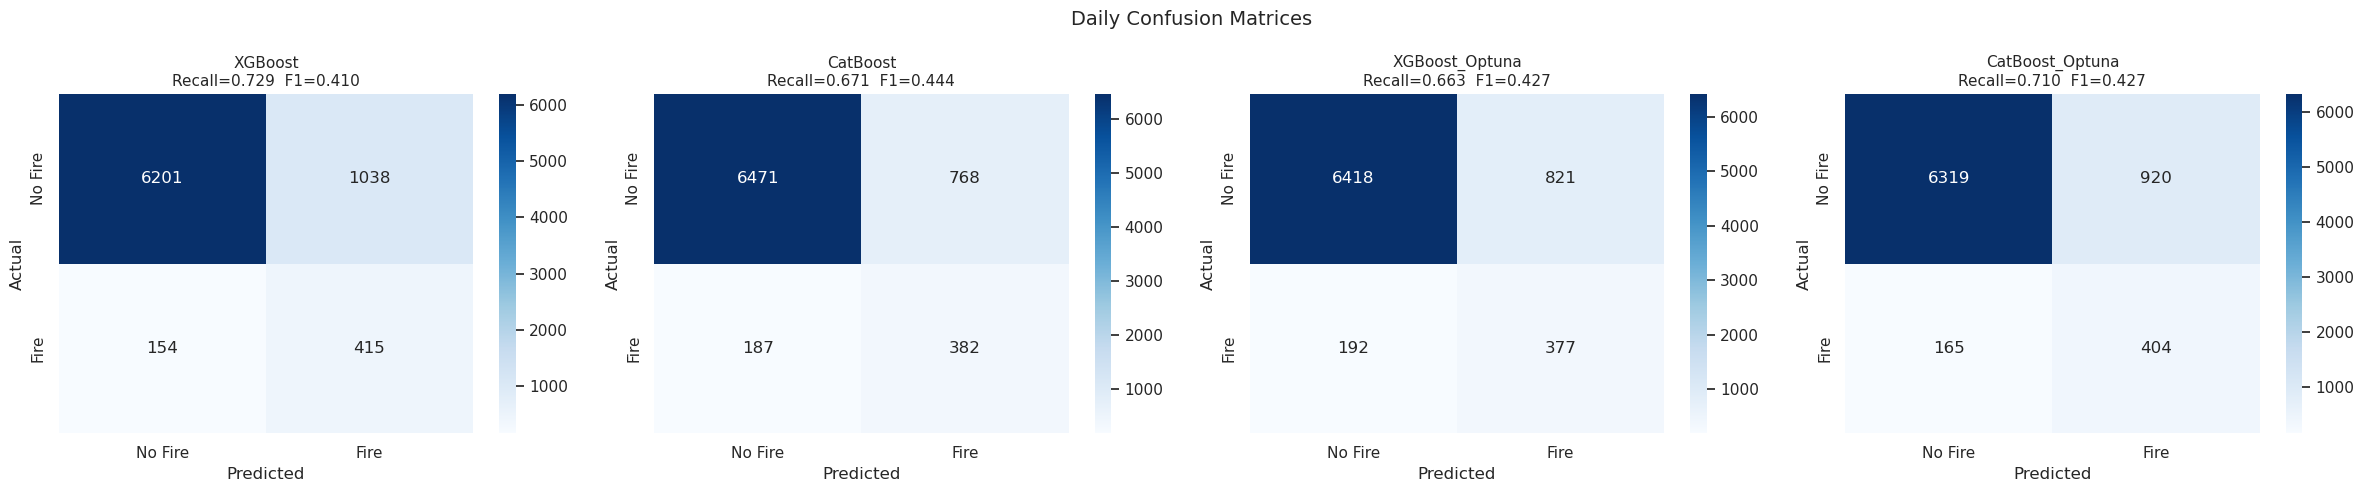

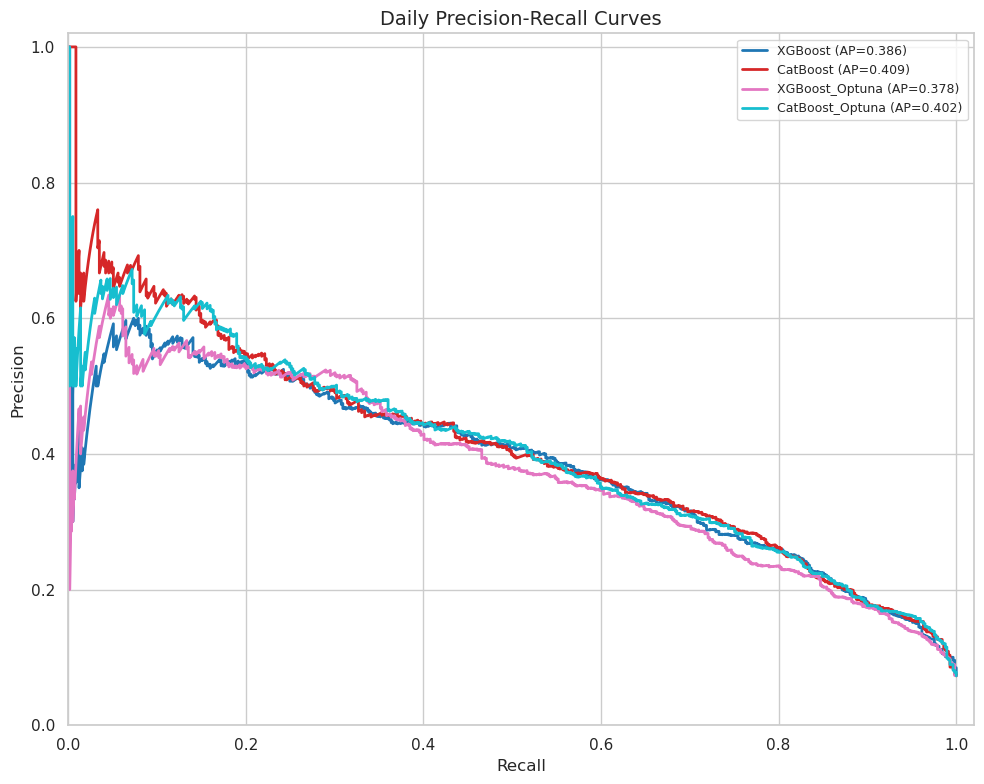

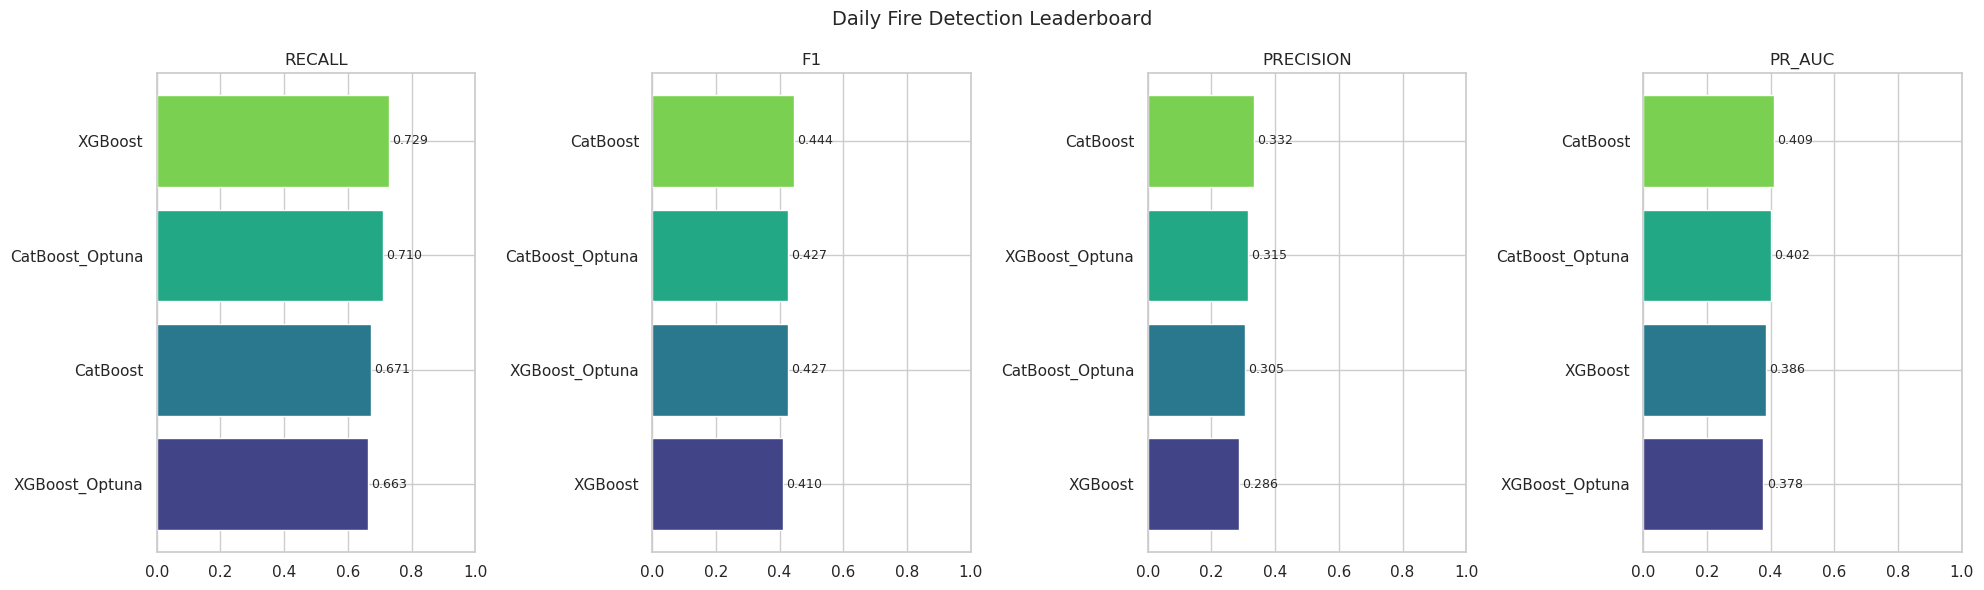


Daily City-level Recall:
  Baku             fires=130  recall=0.846  precision=0.382  f1=0.526
  Barda            fires= 61  recall=0.787  precision=0.397  f1=0.527
  Gabala           fires=  3  recall=0.333  precision=0.111  f1=0.167
  Ganja            fires= 29  recall=0.759  precision=0.234  f1=0.358
  Jalilabad        fires= 37  recall=0.784  precision=0.266  f1=0.397
  Khachmaz         fires= 26  recall=0.615  precision=0.229  f1=0.333
  Lankaran         fires= 19  recall=0.632  precision=0.267  f1=0.375
  Mingachevir      fires= 45  recall=0.844  precision=0.322  f1=0.466
  Nakhchivan       fires= 26  recall=0.308  precision=0.211  f1=0.250
  Quba             fires= 21  recall=0.619  precision=0.277  f1=0.382
  Shabran          fires=  0
  Shaki            fires= 48  recall=0.667  precision=0.330  f1=0.441
  Shamakhi         fires= 12  recall=0.500  precision=0.107  f1=0.176
  Shirvan          fires= 59  recall=0.610  precision=0.279  f1=0.383
  Yevlakh          fires= 43  recal

In [7]:
# ─── §6: Daily evaluation plots ──────────────────────────────────────────

# 6a. Confusion matrices — all models
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(6*len(model_names), 5))
if len(model_names) == 1: axes = [axes]
fig.suptitle("Daily Confusion Matrices", fontsize=14)
for ax, nm in zip(axes, model_names):
    r = results[nm]
    plot_confusion_matrix(r["y_true"], r["y_pred"], title=nm, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# 6b. PR curves
fig, ax = plt.subplots(figsize=(10, 8))
curves = {nm: r["y_prob"] for nm, r in results.items()}
plot_pr_curves(curves, y_test, title="Daily Precision-Recall Curves", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# 6c. Leaderboard chart
fig = plot_leaderboard(leaderboard, title="Daily Fire Detection Leaderboard")
if fig:
    plt.savefig(FIGURES / "fire_leaderboard_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

# 6d. City-level recall
print("\nDaily City-level Recall:")
tmp = test_df[["City", TARGET_COL]].copy()
tmp["pred"] = FINAL_PRED
city_met = []
for city in sorted(tmp["City"].unique()):
    cm = tmp[tmp["City"] == city]
    nf = int(cm[TARGET_COL].sum())
    if nf > 0:
        r = recall_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        p = precision_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        f = f1_score(cm[TARGET_COL], cm["pred"], zero_division=0)
    else:
        r, p, f = np.nan, np.nan, np.nan
    city_met.append({"City": city, "n_fires": nf, "recall": r, "precision": p, "f1": f})
    if nf > 0:
        print(f"  {city:15s}  fires={nf:3d}  recall={r:.3f}  precision={p:.3f}  f1={f:.3f}")
    else:
        print(f"  {city:15s}  fires=  0")
pd.DataFrame(city_met).to_csv(METRICS / "fire_city_metrics.csv", index=False)

# 6e. Overfitting diagnostic
print("\nOverfitting Diagnostic (train-vs-test F1 gap):")
for nm, r in sorted(results.items(), key=lambda x: x[1].get("overfit_gap", 0), reverse=True):
    g = r.get("overfit_gap", 0)
    flag = " ← WARNING" if g > 0.15 else ""
    print(f"  {nm:30s}  gap={g:+.3f}{flag}")

## §7 — Daily Feature Importance & SHAP Explainability

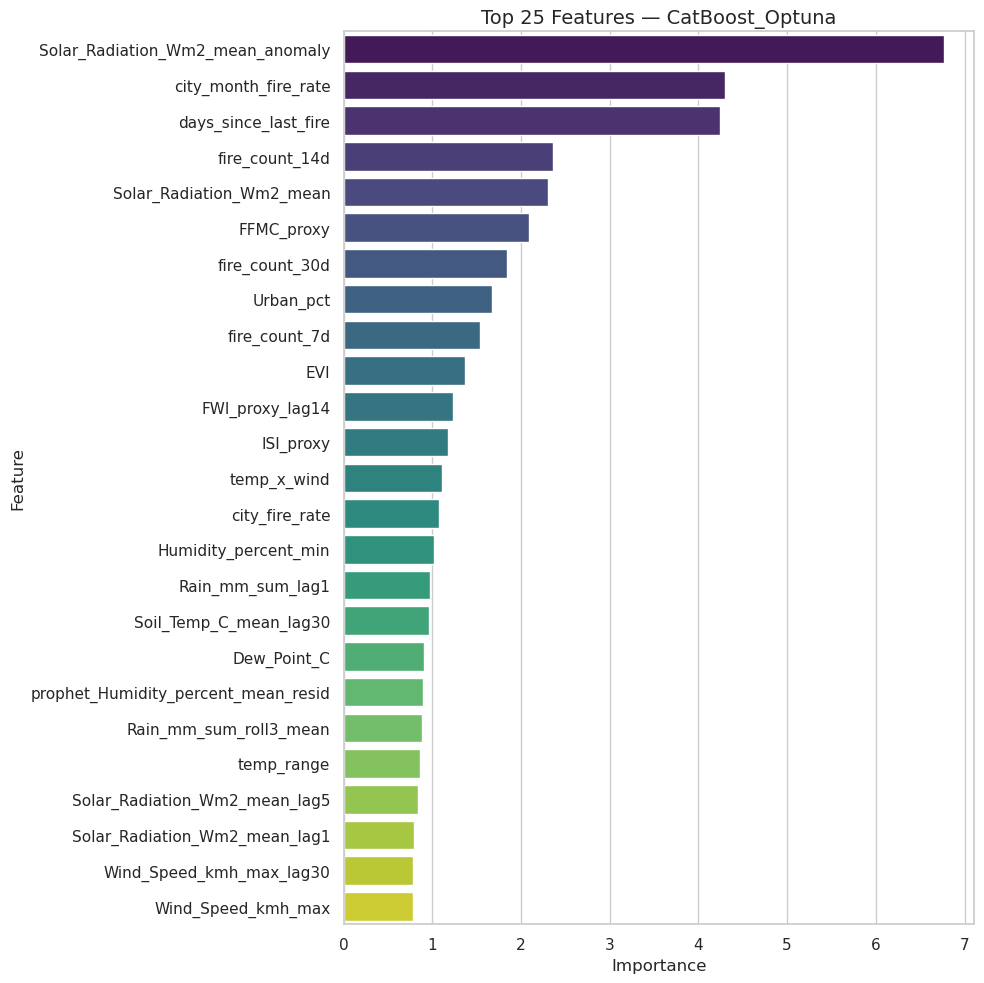

Computing SHAP values (2 000 sample) …


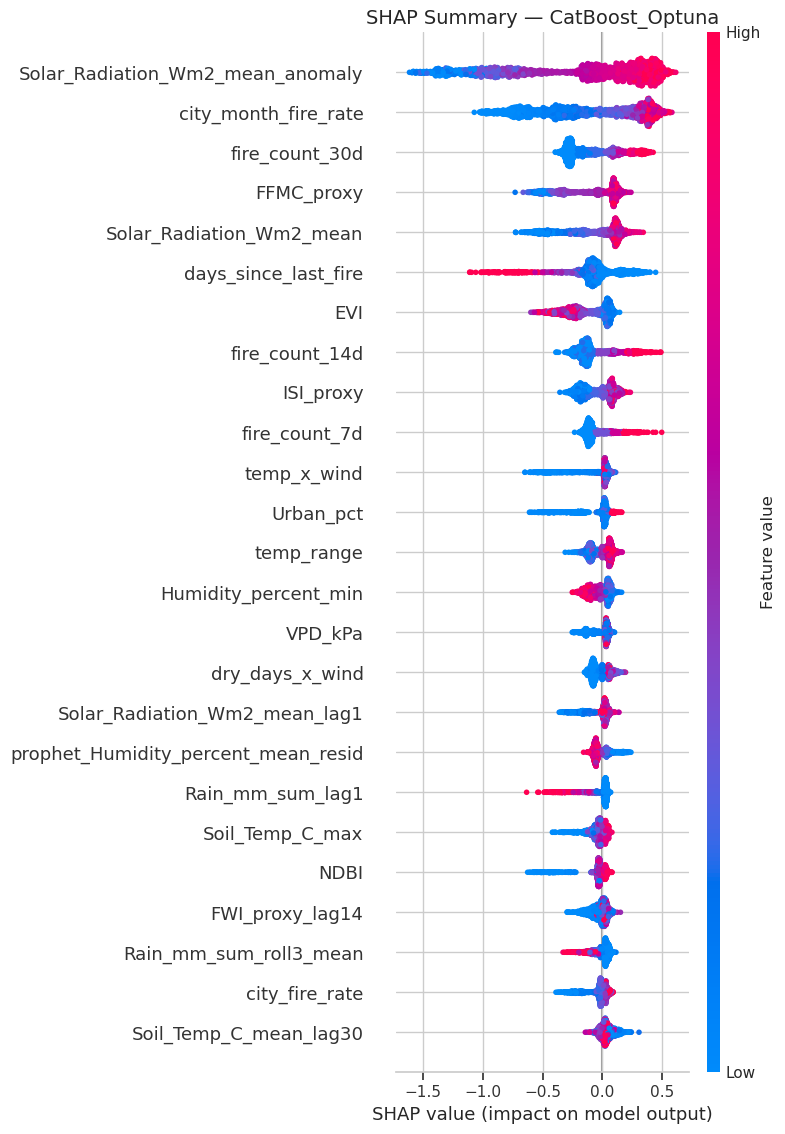

SHAP complete.


In [8]:
# ─── §7: SHAP + feature importance ───────────────────────────────────────

raw_model = best_model

if hasattr(raw_model, "feature_importances_"):
    imp = raw_model.feature_importances_
elif hasattr(raw_model, "coef_"):
    imp = np.abs(raw_model.coef_).ravel()
else:
    imp = np.zeros(len(feature_cols))

fi = pd.DataFrame({"Feature": feature_cols, "Importance": imp})
fi = fi.sort_values("Importance", ascending=False).reset_index(drop=True)
fi.to_csv(METRICS / "fire_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 10))
plot_feature_importance(fi["Feature"].values, fi["Importance"].values,
                        top_n=25, title=f"Top 25 Features — {BEST_NAME}", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    import shap
    print("Computing SHAP values (2 000 sample) …")
    idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
    X_shap = X_test.iloc[idx]
    explainer = shap.TreeExplainer(raw_model)
    sv = explainer.shap_values(X_shap)
    if isinstance(sv, list): sv = sv[1]

    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(sv, X_shap, max_display=25, show=False)
    plt.title(f"SHAP Summary — {BEST_NAME}", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES / "fire_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("SHAP complete.")
except ImportError:
    print("shap not installed — pip install shap")
except Exception as e:
    print(f"SHAP failed: {e}")

## §8 — Save Daily Model Artifacts

In [9]:
# ─── §8: Save daily artifacts ────────────────────────────────────────────
MODELS_F.mkdir(parents=True, exist_ok=True)

model_path = MODELS_F / "best_fire_model.joblib"
jl_dump(FINAL_MODEL, model_path)
print(f"Model:    {model_path}")

feat_path = MODELS_F / "feature_columns.json"
with open(feat_path, "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Features: {feat_path}")

if hasattr(best_model, "save_model"):
    json_path = MODELS_F / "best_fire_model.json"
    best_model.save_model(str(json_path))
    print(f"XGB JSON: {json_path}")

manifest = {
    "model_name": BEST_NAME,
    "optimal_threshold": float(FINAL_THRESH),
    "n_features": len(feature_cols),
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "imbalance_ratio": float(IMBALANCE_RATIO),
    "train_shape": list(X_train.shape),
    "val_shape":   list(X_val.shape),
    "test_shape":  list(X_test.shape),
    "metrics": {k: float(v) for k, v in m_final.items()},
    "overfit_gap": float(best_result.get("overfit_gap", 0)),
    "total_models_compared": len(results),
}
manifest_path = MODELS_F / "model_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Manifest: {manifest_path}")

print(f"\n✓ Daily pipeline complete — {BEST_NAME}")

Model:    /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model.joblib
Features: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/feature_columns.json
XGB JSON: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model.json
Manifest: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/model_manifest.json

✓ Daily pipeline complete — CatBoost_Optuna


---

# PART B — Hourly Fire Detection (168h)

Same 2-model approach (XGBoost + CatBoost) on **hourly** engineered data. The hourly model enables 168-hour (7-day) fire risk forecasts at hour-level granularity.

**Input:** `data/processed/engineered_hourly.parquet`  
**Output:** `models/wildfire/best_fire_model_hourly.joblib`, `models/wildfire/model_manifest_hourly.json`

In [10]:
# ─── PART B: Hourly fire detection pipeline ──────────────────────────────
print("=" * 60)
print("  HOURLY FIRE DETECTION")
print("=" * 60)

# ── B1. Load hourly data ─────────────────────────────────────────────────
h_path = ENG_HOURLY
if not h_path.exists():
    raise FileNotFoundError(f"Missing {h_path} — run NB02 first")

h_df = pd.read_parquet(h_path)
h_df["Date"] = pd.to_datetime(h_df["Date"])
h_df["Timestamp"] = pd.to_datetime(h_df["Timestamp"])
h_df = h_df.sort_values(["City", "Timestamp"]).reset_index(drop=True)
print(f"\nLoaded: {h_df.shape}  from {h_path.name}")
print(f"Fire rate: {h_df[TARGET_COL].mean()*100:.2f}%")

# ── B2. Temporal split ───────────────────────────────────────────────────
h_train = h_df[h_df["Date"] <  VAL_DATE].copy()
h_val   = h_df[(h_df["Date"] >= VAL_DATE) & (h_df["Date"] < TEST_DATE)].copy()
h_test  = h_df[h_df["Date"] >= TEST_DATE].copy()

h_exclude = set(DROP_COLS) | {"City", "Date", "Timestamp", "Year"}
h_feat_cols = [c for c in h_df.columns
               if c not in h_exclude
               and c != TARGET_COL
               and h_df[c].dtype in ("float64","float32","int64","int32","uint8")]

hX_train, hy_train = h_train[h_feat_cols].fillna(0), h_train[TARGET_COL]
hX_val,   hy_val   = h_val[h_feat_cols].fillna(0),   h_val[TARGET_COL]
hX_test,  hy_test  = h_test[h_feat_cols].fillna(0),   h_test[TARGET_COL]

h_ir = round((hy_train == 0).sum() / max((hy_train == 1).sum(), 1), 1)

print(f"\n{'Split':10s} {'Rows':>9s} {'Fire%':>7s}")
print("-" * 30)
for nm, y in [("Train", hy_train), ("Val", hy_val), ("Test", hy_test)]:
    print(f"{nm:10s} {len(y):9,d} {y.mean()*100:6.2f}%")
print(f"Imbalance ratio: {h_ir}")
print(f"Features: {len(h_feat_cols)}")

# ── B3. Feature pruning ─────────────────────────────────────────────────
n_hb = len(h_feat_cols)
h_stds = hX_train.std()
h_low_var = h_stds[h_stds < 0.001].index.tolist()
h_keep = [c for c in h_feat_cols if c not in h_low_var]

h_corr = hX_train[h_keep].corr().abs()
h_fire_corr = hX_train[h_keep].corrwith(hy_train).abs()
h_drop = set()
for i in range(len(h_corr.columns)):
    for j in range(i + 1, len(h_corr.columns)):
        if h_corr.iloc[i, j] > 0.95:
            ci, cj = h_corr.columns[i], h_corr.columns[j]
            if ci in h_drop or cj in h_drop:
                continue
            drop = cj if h_fire_corr.get(ci, 0) >= h_fire_corr.get(cj, 0) else ci
            h_drop.add(drop)

h_feat_cols = [c for c in h_keep if c not in h_drop]
hX_train = hX_train[h_feat_cols]
hX_val   = hX_val[h_feat_cols]
hX_test  = hX_test[h_feat_cols]
print(f"\nHourly features: {n_hb} → {len(h_feat_cols)} (pruned {n_hb - len(h_feat_cols)})")

# ── B4. Train 2 baselines ───────────────────────────────────────────────
h_results = {}

print(f"\n{'Model':15s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Gap':>6s} {'Time':>6s}")
print("-" * 70)

h_models = {
    "XGBoost_H": xgb.XGBClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=h_ir,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=25,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "CatBoost_H": cb.CatBoostClassifier(
        iterations=300, depth=7, learning_rate=0.05,
        auto_class_weights="Balanced", l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0),
}

for nm, mdl in h_models.items():
    t0 = time.time()
    if "XGB" in nm:
        mdl.fit(hX_train, hy_train, eval_set=[(hX_val, hy_val)], verbose=False)
    else:
        mdl.fit(hX_train, hy_train)
    yp_v = mdl.predict_proba(hX_val)[:,1]
    yp_t = mdl.predict_proba(hX_test)[:,1]
    yp_tr = mdl.predict_proba(hX_train)[:,1]
    thr = find_optimal_threshold(hy_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    m = fire_metrics(hy_test, yd_t, yp_t)
    tr_f1 = f1_score(hy_train, (yp_tr >= thr).astype(int), zero_division=0)
    gap = tr_f1 - m["f1"]
    h_results[nm] = {
        "model": mdl, "y_true": hy_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": "class_weight",
        "train_time": time.time() - t0,
        "train_f1": tr_f1, "overfit_gap": gap,
    }
    print(f"{nm:15s} {thr:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
          f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {gap:+6.3f} {time.time()-t0:5.1f}s")

# ── B5. Optuna tuning ───────────────────────────────────────────────────
H_TRIALS = 40

for base_name, obj_fn_factory in [("XGBoost_H", _xgb_objective), ("CatBoost_H", _cb_objective)]:
    print(f"\n{'='*50}\n  OPTUNA — {base_name} ({H_TRIALS} trials)\n{'='*50}")
    obj_fn = lambda trial: obj_fn_factory(trial, hX_train, hy_train, hX_val, hy_val, h_ir)
    study = optuna.create_study(direction="maximize", study_name=f"hourly_{base_name}")
    study.optimize(obj_fn, n_trials=H_TRIALS, show_progress_bar=True)
    bp = study.best_trial.params
    print(f"  Best val score: {study.best_trial.value:.4f}")

    tag = f"{base_name}_Optuna"
    if "XGB" in base_name:
        tuned = xgb.XGBClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            gamma=bp["gamma"], reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            eval_metric="aucpr", early_stopping_rounds=25,
            random_state=SEED, use_label_encoder=False, n_jobs=-1)
        tuned.fit(hX_train, hy_train, eval_set=[(hX_val, hy_val)], verbose=False)
    else:
        tuned = cb.CatBoostClassifier(
            iterations=bp["iterations"], depth=bp["depth"],
            learning_rate=bp["lr"], l2_leaf_reg=bp["l2"],
            subsample=bp.get("subsample", 0.8),
            auto_class_weights="Balanced",
            random_seed=SEED, verbose=0)
        tuned.fit(hX_train, hy_train)

    yp_v = tuned.predict_proba(hX_val)[:,1]
    yp_t = tuned.predict_proba(hX_test)[:,1]
    yp_tr = tuned.predict_proba(hX_train)[:,1]
    thr = find_optimal_threshold(hy_val, yp_v, min_precision=MIN_PRECISION, min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    m = fire_metrics(hy_test, yd_t, yp_t)
    tr_f1 = f1_score(hy_train, (yp_tr >= thr).astype(int), zero_division=0)
    h_results[tag] = {
        "model": tuned, "y_true": hy_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": f"optuna_{H_TRIALS}t",
        "train_time": 0, "train_f1": tr_f1,
        "overfit_gap": tr_f1 - m["f1"], "best_params": bp,
    }
    print(f"  Test → Thr={thr:.2f}  Recall={m['recall']:.4f}  Prec={m['precision']:.4f}  "
          f"F1={m['f1']:.4f}  PR-AUC={m.get('pr_auc',0):.4f}")

# ── B6. Select best hourly model ─────────────────────────────────────────
h_leaderboard = build_fire_leaderboard(h_results)
print("\nHOURLY LEADERBOARD")
print("=" * 80)
h_avail = [c for c in ["model","threshold","recall","precision","f1","pr_auc","composite"]
           if c in h_leaderboard.columns]
print(h_leaderboard[h_avail].to_string(index=False))

H_BEST_NAME = h_leaderboard.iloc[0]["model"]
h_best = h_results[H_BEST_NAME]
h_best_model = h_best["model"]
H_THRESH = h_best["threshold"]
h_m_final = fire_metrics(hy_test, h_best["y_pred"], h_best["y_prob"])

print(f"\nBEST HOURLY MODEL: {H_BEST_NAME}")
print(f"  Recall={h_m_final['recall']:.4f}  Prec={h_m_final['precision']:.4f}  "
      f"F1={h_m_final['f1']:.4f}  PR-AUC={h_m_final.get('pr_auc',0):.4f}")

h_leaderboard.to_csv(METRICS / "fire_leaderboard_hourly.csv", index=False)

# ── B7. Save hourly artifacts ────────────────────────────────────────────
h_model_path = MODELS_F / "best_fire_model_hourly.joblib"
jl_dump(h_best_model, h_model_path)
print(f"\nHourly model: {h_model_path}")

h_feat_path = MODELS_F / "feature_columns_hourly.json"
with open(h_feat_path, "w") as f:
    json.dump(h_feat_cols, f, indent=2)
print(f"Hourly features: {h_feat_path}")

if hasattr(h_best_model, "save_model"):
    h_json_path = MODELS_F / "best_fire_model_hourly.json"
    h_best_model.save_model(str(h_json_path))
    print(f"Hourly XGB JSON: {h_json_path}")

h_manifest = {
    "model_name": H_BEST_NAME,
    "optimal_threshold": float(H_THRESH),
    "n_features": len(h_feat_cols),
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "imbalance_ratio": float(h_ir),
    "train_shape": list(hX_train.shape),
    "val_shape":   list(hX_val.shape),
    "test_shape":  list(hX_test.shape),
    "metrics": {k: float(v) for k, v in h_m_final.items()},
    "overfit_gap": float(h_best.get("overfit_gap", 0)),
    "total_models_compared": len(h_results),
}
h_manifest_path = MODELS_F / "model_manifest_hourly.json"
with open(h_manifest_path, "w") as f:
    json.dump(h_manifest, f, indent=2, default=str)
print(f"Hourly manifest: {h_manifest_path}")

  HOURLY FIRE DETECTION

Loaded: (2003712, 99)  from engineered_hourly.parquet
Fire rate: 8.07%

Split           Rows   Fire%
------------------------------
Train      1,675,840   8.32%
Val          140,544   6.11%
Test         187,328   7.29%
Imbalance ratio: 11.0
Features: 88

Hourly features: 88 → 68 (pruned 20)

Model             Thr  Recall    Prec      F1  PR-AUC    Gap   Time
----------------------------------------------------------------------
XGBoost_H        0.50  0.6535  0.2483  0.3598  0.3712 +0.045  69.4s
CatBoost_H       0.50  0.6829  0.2514  0.3675  0.3670 +0.024 122.4s

  OPTUNA — XGBoost_H (40 trials)


  0%|          | 0/40 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.6213  Prec=0.2576  F1=0.3642  PR-AUC=0.3482

  OPTUNA — CatBoost_H (40 trials)


  0%|          | 0/40 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.6611  Prec=0.2506  F1=0.3635  PR-AUC=0.3509

HOURLY LEADERBOARD
            model  threshold   recall  precision       f1   pr_auc  composite
       CatBoost_H        0.5 0.682850   0.251361 0.367459 0.367016   0.427247
CatBoost_H_Optuna        0.5 0.661101   0.250645 0.363483 0.350922   0.418917
        XGBoost_H        0.5 0.653486   0.248254 0.359817 0.371172   0.414449
 XGBoost_H_Optuna        0.5 0.621265   0.257590 0.364183 0.348218   0.409330

BEST HOURLY MODEL: CatBoost_H
  Recall=0.6829  Prec=0.2514  F1=0.3675  PR-AUC=0.3670

Hourly model: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model_hourly.joblib
Hourly features: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/feature_columns_hourly.json
Hourly XGB JSON: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model_hourly.json
Hourly manifest: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/model_manif

In [11]:
# ─── NB04 FINAL SUMMARY ──────────────────────────────────────────────────
print("=" * 60)
print("NB04 COMPLETE")
print("=" * 60)

print(f"\n  DAILY MODEL:  {BEST_NAME}")
print(f"    Recall={m_final['recall']:.4f}  Prec={m_final['precision']:.4f}  "
      f"F1={m_final['f1']:.4f}  PR-AUC={m_final.get('pr_auc',0):.4f}")
print(f"    Threshold={FINAL_THRESH:.2f}  Models compared={len(results)}")

print(f"\n  HOURLY MODEL: {H_BEST_NAME}")
print(f"    Recall={h_m_final['recall']:.4f}  Prec={h_m_final['precision']:.4f}  "
      f"F1={h_m_final['f1']:.4f}  PR-AUC={h_m_final.get('pr_auc',0):.4f}")
print(f"    Threshold={H_THRESH:.2f}  Models compared={len(h_results)}")

print(f"\n  Artifacts in: {MODELS_F}")
print(f"    best_fire_model.joblib          (daily)")
print(f"    best_fire_model_hourly.joblib   (hourly)")
print(f"    model_manifest.json             (daily)")
print(f"    model_manifest_hourly.json      (hourly)")

print(f"\n→ Next: 05_Risk_Prediction_Dashboard.ipynb")

NB04 COMPLETE

  DAILY MODEL:  CatBoost_Optuna
    Recall=0.7100  Prec=0.3051  F1=0.4268  PR-AUC=0.4021
    Threshold=0.50  Models compared=4

  HOURLY MODEL: CatBoost_H
    Recall=0.6829  Prec=0.2514  F1=0.3675  PR-AUC=0.3670
    Threshold=0.50  Models compared=4

  Artifacts in: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire
    best_fire_model.joblib          (daily)
    best_fire_model_hourly.joblib   (hourly)
    model_manifest.json             (daily)
    model_manifest_hourly.json      (hourly)

→ Next: 05_Risk_Prediction_Dashboard.ipynb
